# Evo2 score comparison

This notebook compares the Evo2 mean log-probability scores for the `atg`, `gfp`, and `randtok` result sets and builds a publication-style figure.

In [4]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

def resolve_score_root():
    candidates = [
        Path("evo2_src/results/evo2_scores"),
        Path.cwd() / "evo2_src/results/evo2_scores",
        Path.cwd() / "results/evo2_scores",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find evo2 score folders. Expected atg/, gfp/, and randtok/ under evo2_src/results/evo2_scores.")


root = resolve_score_root()
groups = {
    "ATG": root / "atg",
    "GFP": root / "gfp",
    "Random tokens": root / "randtok",
}

palette = {
    "ATG": "#1f77b4",
    "GFP": "#2ca02c",
    "Random tokens": "#7f7f7f",
}

print(f"Using score root: {root.resolve()}")

Using score root: /home/acunningham/Projects/plasmidbackbonedesign/plasmidbackbonedesign/evo2_src/results/evo2_scores


In [5]:
def read_score_rows(csv_path: Path):
    rows = []
    with open(csv_path, newline="") as fh:
        reader = csv.DictReader(fh)
        if not reader.fieldnames or "mean_logprob_per_token" not in reader.fieldnames:
            return rows
        for row in reader:
            if not row:
                continue
            rows.append({
                "id": row.get("id", csv_path.stem),
                "length_bp": int(float(row.get("length_bp", 0) or 0)),
                "mean_logprob_per_token": float(row["mean_logprob_per_token"]),
                "source_file": csv_path.name,
            })
    return rows


def load_group(group_dir: Path):
    combined = group_dir / "generations.csv"
    if combined.is_file():
        return read_score_rows(combined)

    rows = []
    for csv_path in sorted(group_dir.glob("*.csv")):
        rows.extend(read_score_rows(csv_path))
    return rows


records = []
for label, group_dir in groups.items():
    for row in load_group(group_dir):
        row = dict(row)
        row["group"] = label
        records.append(row)

df = pd.DataFrame(records)
if df.empty:
    raise FileNotFoundError(f"No Evo2 score rows found under {root}")
df["group"] = pd.Categorical(df["group"], categories=list(groups.keys()), ordered=True)

display(df.head())
print(df.groupby("group", observed=True)["mean_logprob_per_token"].agg(["count", "mean", "median", "std", "min", "max"]))

,id,length_bp,mean_logprob_per_token,source_file,group
0,ft15k_tok50_0001,2804,-1.054688,generations.csv,ATG
1,ft15k_tok50_0002,5031,-1.015625,generations.csv,ATG
2,ft15k_tok50_0003,3890,-1.218750,generations.csv,ATG
3,ft15k_tok50_0004,4764,-0.992188,generations.csv,ATG
4,ft15k_tok50_0005,4412,-0.996094,generations.csv,ATG


               count      mean    median       std       min       max
group                                                                 
ATG             1000 -1.134078 -1.132812  0.108473 -1.359375 -0.675781
GFP             1000 -1.141793 -1.148438  0.090763 -1.343750 -0.796875
Random tokens   1000 -1.376937 -1.375000  0.006157 -1.398438 -1.343750


In [6]:
summary = (
    df.groupby("group", observed=True)
      .agg(
          n=("mean_logprob_per_token", "count"),
          mean=("mean_logprob_per_token", "mean"),
          median=("mean_logprob_per_token", "median"),
          std=("mean_logprob_per_token", "std"),
          min=("mean_logprob_per_token", "min"),
          max=("mean_logprob_per_token", "max"),
          mean_length_bp=("length_bp", "mean"),
      )
      .reset_index()
)

summary["group"] = summary["group"].astype(str)
summary

,group,n,mean,median,std,min,max,mean_length_bp
0,ATG,1000,-1.134078,-1.132812,0.108473,-1.359375,-0.675781,3979.222
1,GFP,1000,-1.141793,-1.148438,0.090763,-1.343750,-0.796875,4002.363
2,Random tokens,1000,-1.376937,-1.375000,0.006157,-1.398438,-1.343750,4002.731


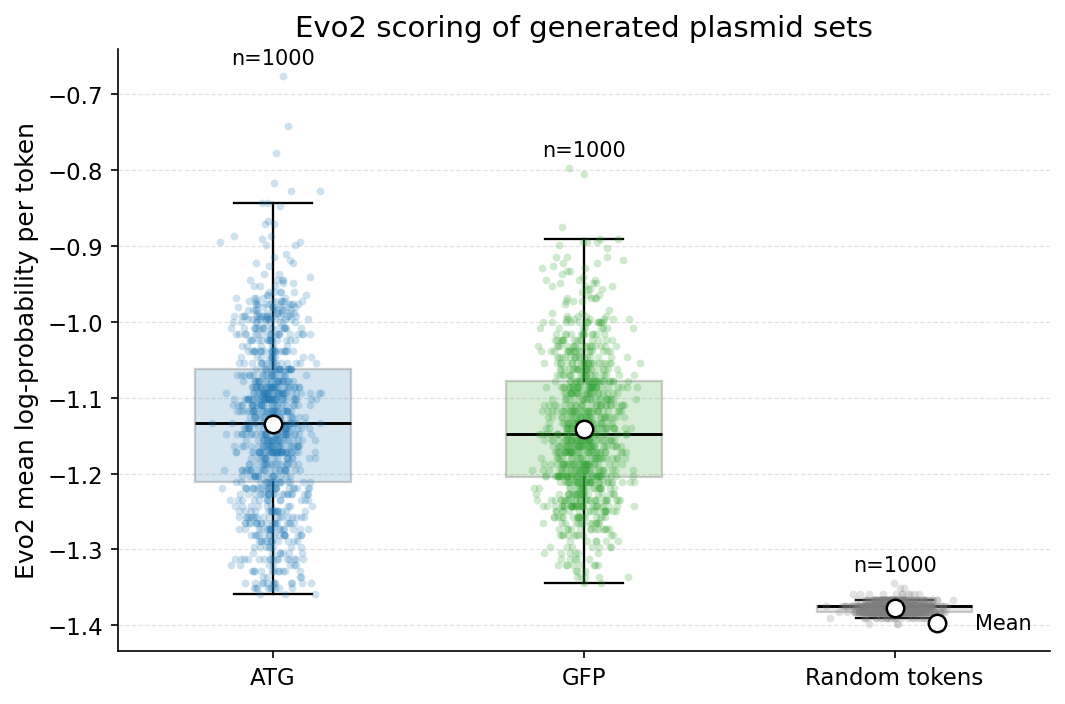

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
order = list(groups.keys())
positions = np.arange(len(order))
rng = np.random.default_rng(7)
series = [df.loc[df["group"] == label, "mean_logprob_per_token"].to_numpy() for label in order]

box = ax.boxplot(
    series,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.4},
    whiskerprops={"linewidth": 1.1, "color": "black"},
    capprops={"linewidth": 1.1, "color": "black"},
    boxprops={"linewidth": 1.1, "edgecolor": "black"},
)

for patch, label in zip(box["boxes"], order):
    patch.set_facecolor(palette[label])
    patch.set_alpha(0.18)

for pos, label, values in zip(positions, order, series):
    jitter = rng.normal(loc=pos, scale=0.06, size=len(values))
    ax.scatter(jitter, values, s=14, color=palette[label], alpha=0.22, linewidths=0, zorder=3)
    ax.scatter(pos, np.mean(values), s=70, color="white", edgecolor="black", linewidth=1.2, zorder=5, label="Mean" if pos == 0 else None)
    ax.text(pos, max(values) + 0.01, f"n={len(values)}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(positions)
ax.set_xticklabels(order)
ax.set_xlabel("")
ax.set_ylabel("Evo2 mean log-probability per token")
ax.set_title("Evo2 scoring of generated plasmid sets")
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()

# fig.savefig("evo2_score_comparison.png", bbox_inches="tight")
# fig.savefig("evo2_score_comparison.pdf", bbox_inches="tight")

plt.show()

In [8]:
best = summary.sort_values("mean", ascending=False).iloc[0]
print(f"Best by mean score: {best['group']} ({best['mean']:.6f})")
summary

Best by mean score: ATG (-1.134078)


,group,n,mean,median,std,min,max,mean_length_bp
0,ATG,1000,-1.134078,-1.132812,0.108473,-1.359375,-0.675781,3979.222
1,GFP,1000,-1.141793,-1.148438,0.090763,-1.343750,-0.796875,4002.363
2,Random tokens,1000,-1.376937,-1.375000,0.006157,-1.398438,-1.343750,4002.731
